# Yokogawa AQ6370C Optical Spectrum Analyzer — GPIB Control

**Instrument:** Yokogawa AQ6370C Optical Spectrum Analyzer (600 – 1700 nm)  
**Interface:** GPIB-USB Adapter — connect to the **GP-IB1 port** (left rear connector)  
**Command set:** SCPI (IEEE 488.2 compliant)  

> ⚠️ The AQ6370C has **two** GPIB connectors on the rear panel.  
> **GP-IB1** (left) = remote control input — use this one.  
> **GP-IB2** (right) = output for controlling external instruments from the OSA — do not use for PC control.

---
**How to use:**
1. Edit the **Configuration Block** (Cell 2) for your GPIB address and measurement parameters.
2. Run Cell 3 (imports & connection) once per session.
3. Run the function definition cell (Cell 4).
4. Use the example cells or call functions directly.

## ⚙️ CONFIGURATION BLOCK — Edit All Parameters Here

In [22]:
# ============================================================
#  GPIB CONNECTION
# ============================================================
GPIB_ADDR_AQ6370C  = 1      # GPIB address (System → GPIB menu on instrument)
GPIB_BOARD_INDEX   = 1      # USB-GPIB adapter index (0 = first/only adapter)

# ============================================================
#  SWEEP PARAMETERS
# ============================================================
OSA_CENTER_WL_NM   = 1550.0  # Center wavelength nm    (600 – 1700)
OSA_SPAN_NM        = 20.0   # Span nm                 (0 – 1100)
OSA_RESOLUTION_NM  = 0.02     # Resolution nm           (0.02 – 2.0)
OSA_SENSITIVITY    = 'NAUT'  # Sensitivity mode — see table in manual
OSA_SWEEP_MODE     = 'AUTO'  # 'SING', 'REP', 'AUTO', 'SEGM'
OSA_POINTS         = 20001   # Sample points           (51 – 50001)

# ============================================================
#  DISPLAY
# ============================================================
OSA_ACTIVE_TRACE   = 'TRA'   # Active trace: 'TRA' … 'TRG'
OSA_REF_LEVEL_DBM  = 0.0     # Reference level dBm
OSA_LEVEL_SCALE    = 10.0    # dB per division         (0.1 – 10)

# ============================================================
#  START / STOP  (alternative to center / span)
# ============================================================
OSA_START_WL_NM    = 1540.0  # Start wavelength nm
OSA_STOP_WL_NM     = 1560.0  # Stop wavelength nm

# ============================================================
#  WDM / ANALYSIS
# ============================================================
OSA_THRESH_DB      = 20.0    # Threshold below peak for WDM channel detection dB

# ============================================================
#  FILE OUTPUT
# ============================================================
OUTPUT_DIR         = './data_osa'  # Directory for saved CSVs and PNGs

# ============================================================
#  TIMING
# ============================================================
QUERY_DELAY_S      = 0.1     # Seconds to wait between write and read
SWEEP_TIMEOUT_S    = 1800     # Max seconds to wait for sweep (HIGH3 can be slow)

print("AQ6370C configuration loaded.")

AQ6370C configuration loaded.


## 📦 Imports & Instrument Connection

In [3]:
import pyvisa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
import datetime

os.makedirs(OUTPUT_DIR, exist_ok=True)

rm = pyvisa.ResourceManager()
print("Available VISA resources:")
print(rm.list_resources())

# Open the AQ6370C
# NOTE: AQ6370C requires LF (\n) terminator on every command.
osa = rm.open_resource(f'GPIB{GPIB_BOARD_INDEX}::{GPIB_ADDR_AQ6370C}::INSTR')
osa.timeout          = 60000   # 60 s — HIGH3 sensitivity sweeps can be slow
osa.read_termination  = '\n'
osa.write_termination = '\n'

# Some adapters need slower bus timing with this instrument
# If you get timeout errors, try setting NI-MAX bus timing to 1 µs

try:
    idn = osa.query('*IDN?').strip()
    print(f"Connected: {idn}")
except Exception as e:
    print(f"IDN query failed: {e}")
    print("Check cable is on GP-IB1 (left rear port) and GPIB address matches.")

Available VISA resources:
('ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'ASRL8::INSTR', 'ASRL10::INSTR', 'ASRL13::INSTR', 'ASRL14::INSTR', 'GPIB0::18::INSTR', 'GPIB0::1::INSTR', 'GPIB0::2::INSTR', 'GPIB1::1::INSTR')
Connected: YOKOGAWA,AQ6370C,91MA25623,04.06


## 🔧 Function Definitions

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
#  YOKOGAWA AQ6370C OSA — COMPLETE FUNCTION LIBRARY
# ══════════════════════════════════════════════════════════════════════════════

# ── Instrument Control ────────────────────────────────────────────────────────

def osa_reset():
    """Reset the AQ6370C to factory defaults. Waits 3 s for recovery."""
    osa.write('*RST')
    osa.write('*CLS')
    time.sleep(3)
    print("AQ6370C reset complete.")


def osa_clear():
    """Send GPIB Device Clear to recover from bus hang or error."""
    osa.clear()
    osa.write('*CLS')
    print("AQ6370C cleared.")


def osa_go_to_local():
    """Return front-panel control to the operator."""
    osa.write('*GTL')
    print("AQ6370C returned to local control.")


def osa_get_idn():
    """Query and return the instrument identification string."""
    idn = osa.query('*IDN?').strip()
    print(f"IDN: {idn}")
    return idn


# ── Wavelength / Span Configuration ──────────────────────────────────────────

def osa_configure(
    center_nm=OSA_CENTER_WL_NM,
    span_nm=OSA_SPAN_NM,
    resolution_nm=OSA_RESOLUTION_NM,
    sensitivity=OSA_SENSITIVITY,
    points=OSA_POINTS,
    ref_dbm=OSA_REF_LEVEL_DBM,
    level_scale=OSA_LEVEL_SCALE
):
    """
    Configure all primary OSA sweep and display parameters.

    Parameters
    ----------
    center_nm    : Center wavelength nm  (600–1700)
    span_nm      : Span nm  (0–1100; 0 = fixed wavelength)
    resolution_nm: Resolution bandwidth nm  (0.02–2.0)
    sensitivity  : 'NHLD','NAUT','MID','HIGH1','HIGH2','HIGH3'
    points       : Sample points  (51–50001)
    ref_dbm      : Reference level dBm
    level_scale  : dB per division  (0.1–10)
    """
    osa.write(f':SENS:WAV:CENT {center_nm:.3f}NM')
    osa.write(f':SENS:WAV:SPAN {span_nm:.3f}NM')
    osa.write(f':SENS:BAND:RES {resolution_nm:.3f}NM')
    osa.write(f':SENS:SENS {sensitivity}')
    osa.write(f':SENS:SWE:POIN {int(points)}')
    osa.write(f':DISP:TRAC:Y:RLEV {ref_dbm:.1f}DBM')
    osa.write(f':DISP:TRAC:Y:PDIV {level_scale:.1f}')
    print(f"OSA configured: CWL={center_nm:.3f} nm, SPAN={span_nm:.3f} nm, "
          f"RES={resolution_nm:.3f} nm, SENS={sensitivity}, POINTS={points}")


def osa_set_center_wavelength(center_nm):
    """
    Set only the center wavelength.

    Parameters
    ----------
    center_nm : Center wavelength nm
    """
    osa.write(f':SENS:WAV:CENT {center_nm:.3f}NM')
    print(f"OSA center wavelength: {center_nm:.3f} nm")


def osa_set_span(span_nm):
    """
    Set only the wavelength span.

    Parameters
    ----------
    span_nm : Span nm  (0 = fixed-wavelength / zero-span)
    """
    osa.write(f':SENS:WAV:SPAN {span_nm:.3f}NM')
    print(f"OSA span: {span_nm:.3f} nm")


def osa_set_wavelength_range(start_nm=OSA_START_WL_NM, stop_nm=OSA_STOP_WL_NM):
    """
    Set the sweep window by explicit start and stop wavelengths.

    Parameters
    ----------
    start_nm : Start wavelength nm
    stop_nm  : Stop wavelength nm
    """
    osa.write(f':SENS:WAV:STAR {start_nm:.3f}NM')
    osa.write(f':SENS:WAV:STOP {stop_nm:.3f}NM')
    print(f"OSA range: {start_nm:.3f} – {stop_nm:.3f} nm")


def osa_set_resolution(resolution_nm):
    """
    Set the resolution bandwidth.

    Parameters
    ----------
    resolution_nm : Resolution nm  (0.02–2.0)
    """
    osa.write(f':SENS:BAND:RES {resolution_nm:.3f}NM')
    print(f"OSA resolution: {resolution_nm:.3f} nm")


def osa_set_sensitivity(mode=OSA_SENSITIVITY):
    """
    Set the sensitivity mode.

    Parameters
    ----------
    mode : 'NHLD' | 'NAUT' | 'MID' | 'HIGH1' | 'HIGH2' | 'HIGH3'
           NHLD = fastest/least sensitive; HIGH3 = slowest/most sensitive
    """
    osa.write(f':SENS:SENS {mode}')
    print(f"OSA sensitivity: {mode}")


def osa_set_points(points):
    """
    Set the number of sample points per sweep.

    Parameters
    ----------
    points : Integer  (51–50001)
    """
    osa.write(f':SENS:SWE:POIN {int(points)}')
    print(f"OSA sample points: {points}")


def osa_set_ref_level(ref_dbm):
    """
    Set the display reference level.

    Parameters
    ----------
    ref_dbm : Reference level dBm
    """
    osa.write(f':DISP:TRAC:Y:RLEV {ref_dbm:.1f}DBM')
    print(f"OSA reference level: {ref_dbm:.1f} dBm")


def osa_query_settings():
    """
    Query and print current center wavelength, span, resolution, and sensitivity.

    Returns
    -------
    dict with keys: center_nm, span_nm, start_nm, stop_nm, resolution_nm, sensitivity
    """
    settings = {
        'center_nm':    float(osa.query(':SENS:WAV:CENT?').strip()) * 1e9,
        'span_nm':      float(osa.query(':SENS:WAV:SPAN?').strip()) * 1e9,
        'start_nm':     float(osa.query(':SENS:WAV:STAR?').strip()) * 1e9,
        'stop_nm':      float(osa.query(':SENS:WAV:STOP?').strip()) * 1e9,
        'resolution_nm':float(osa.query(':SENS:BAND:RES?').strip()) * 1e9,
        'sensitivity':  osa.query(':SENS:SENS?').strip(),
        'points':       int(osa.query(':SENS:SWE:POIN?').strip()),
    }
    for k, v in settings.items():
        print(f"  {k}: {v}")
    return settings


# ── Sweep Control ─────────────────────────────────────────────────────────────

def osa_single_sweep(trace=OSA_ACTIVE_TRACE):
    """
    Execute a single sweep and block until completion.
    Polls the operation event register bit 0 (sweep complete).

    Parameters
    ----------
    trace : Target trace for the result  ('TRA'…'TRG')
    """
    osa.write(f':TRAC:ACT {trace}')
    osa.write(':INIT:SMOD SING')
    osa.write(':INIT')
    deadline = time.time() + SWEEP_TIMEOUT_S
    while time.time() < deadline:
        try:
            status = int(osa.query(':STAT:OPER:EVEN?').strip())
            if status & 1:
                break
        except Exception:
            pass
        time.sleep(0.5)
    else:
        print("WARNING: OSA sweep timed out.")
    print(f"OSA single sweep complete (trace {trace}).")


def osa_repeat_sweep(trace=OSA_ACTIVE_TRACE):
    """Start continuous / repeat sweep mode."""
    osa.write(f':TRAC:ACT {trace}')
    osa.write(':INIT:SMOD REP')
    osa.write(':INIT')
    print("OSA repeat sweep started.")


def osa_stop_sweep():
    """Abort an in-progress sweep."""
    osa.write(':ABOR')
    print("OSA sweep aborted.")


# ── Trace Operations ──────────────────────────────────────────────────────────

def osa_set_active_trace(trace):
    """
    Set the active trace.

    Parameters
    ----------
    trace : 'TRA', 'TRB', 'TRC', 'TRD', 'TRE', 'TRF', or 'TRG'
    """
    osa.write(f':TRAC:ACT {trace}')
    print(f"OSA active trace: {trace}")


def osa_set_trace_display(trace, mode):
    """
    Set a trace display mode.

    Parameters
    ----------
    trace : Trace identifier
    mode  : 'WRITE', 'FIX', 'MAX', 'MIN', 'CALC', or 'OFF'
    """
    osa.write(f':TRAC:ATTR:{trace} {mode}')
    print(f"OSA trace {trace} mode: {mode}")


# ── Data Acquisition ──────────────────────────────────────────────────────────

def osa_fetch_trace(trace=OSA_ACTIVE_TRACE):
    """
    Read X (wavelength) and Y (power) data for the specified trace.
    The OSA returns wavelength in metres; this function converts to nm.

    Parameters
    ----------
    trace : Trace identifier  ('TRA'…'TRG')

    Returns
    -------
    (wavelengths, powers) : numpy arrays in nm and dBm
    """
    osa.write('FORMAT:DATA ASCII')
    raw_x = osa.query(f':TRAC:DATA:X? {trace}').strip()
    raw_y = osa.query(f':TRAC:DATA:Y? {trace}').strip()
    wavelengths = np.array([float(v) for v in raw_x.split(',')]) * 1e9
    powers      = np.array([float(v) for v in raw_y.split(',')])
    print(f"Fetched {len(wavelengths)} points from {trace}: "
          f"{wavelengths[0]:.3f} – {wavelengths[-1]:.3f} nm")
    return wavelengths, powers


# ── Marker / Analysis ─────────────────────────────────────────────────────────

def osa_peak_search(trace=OSA_ACTIVE_TRACE):
    """
    Find the peak of the spectrum and return its wavelength and power.

    Parameters
    ----------
    trace : Trace to search

    Returns
    -------
    (peak_wl_nm, peak_pw_dbm) : tuple of floats
    """
    osa.write(f':CALC:MARK:MAX {trace}')
    time.sleep(QUERY_DELAY_S)
    peak_wl = float(osa.query(':CALC:MARK:X?').strip()) * 1e9
    peak_pw = float(osa.query(':CALC:MARK:Y?').strip())
    print(f"Peak: {peak_wl:.4f} nm  →  {peak_pw:.3f} dBm")
    return peak_wl, peak_pw


def osa_wdm_analysis(trace=OSA_ACTIVE_TRACE, thresh_db=OSA_THRESH_DB):
    """
    Run the built-in WDM channel analysis and return results as a DataFrame.
    For best accuracy, use resolution 0.02–0.1 nm before running.

    Parameters
    ----------
    trace     : Trace to analyze
    thresh_db : Detection threshold below peak (dB)

    Returns
    -------
    df : DataFrame with columns [channel, wavelength_nm, power_dbm, osnr_db]
    """
    osa.write(f':CALC:CAT WDM')
    osa.write(f':CALC:EXEC {trace}')
    time.sleep(3)
    raw = osa.query(':CALC:DATA? WDM').strip()
    records = []
    for i, line in enumerate(raw.split('\n')):
        vals = line.strip().split(',')
        if len(vals) >= 2:
            records.append({
                'channel':      i + 1,
                'wavelength_nm':float(vals[0]) * 1e9,
                'power_dbm':    float(vals[1]),
                'osnr_db':      float(vals[2]) if len(vals) > 2 else np.nan
            })
    df = pd.DataFrame(records)
    print(f"WDM analysis: {len(df)} channels detected.")
    return df


def osa_spectrum_width(trace=OSA_ACTIVE_TRACE, thresh_db=OSA_THRESH_DB):
    """
    Compute the spectral width at a threshold below the peak.

    Parameters
    ----------
    trace     : Trace to analyze
    thresh_db : Threshold below peak dB  (e.g., 3 for −3 dB width)

    Returns
    -------
    width_nm : float — spectral width in nm, or NaN if not found
    """
    wls, pows = osa_fetch_trace(trace)
    peak_idx = np.argmax(pows)
    peak_pw  = pows[peak_idx]
    threshold = peak_pw - thresh_db
    above = wls[pows >= threshold]
    if len(above) < 2:
        print(f"Spectrum width at −{thresh_db} dB: not found (signal too narrow or noisy)")
        return np.nan
    width_nm = above[-1] - above[0]
    print(f"Spectrum width at −{thresh_db} dB: {width_nm:.4f} nm  "
          f"({above[0]:.4f} – {above[-1]:.4f} nm)")
    return width_nm


def osa_osnr(trace=OSA_ACTIVE_TRACE, signal_bw_nm=0.1, noise_offset_nm=0.4):
    """
    Estimate OSNR by comparing peak power to the noise floor at an offset.
    This is a simple single-channel estimate; use osa_wdm_analysis() for
    multi-channel DWDM measurements.

    Parameters
    ----------
    trace          : Trace to analyze
    signal_bw_nm   : Signal bandwidth nm for noise normalization
    noise_offset_nm: Wavelength offset from peak at which noise is sampled

    Returns
    -------
    osnr_db : float
    """
    wls, pows = osa_fetch_trace(trace)
    peak_idx   = np.argmax(pows)
    peak_wl    = wls[peak_idx]
    signal_dbm = pows[peak_idx]
    # Sample noise on both sides of the peak
    noise_pts = pows[(wls > peak_wl + noise_offset_nm) |
                     (wls < peak_wl - noise_offset_nm)]
    if len(noise_pts) == 0:
        print("OSNR: not enough data outside noise offset.")
        return np.nan
    noise_dbm  = np.mean(noise_pts[:20])  # Average a few noise points
    osnr_db    = signal_dbm - noise_dbm
    print(f"OSNR estimate: {osnr_db:.2f} dB  "
          f"(signal={signal_dbm:.2f} dBm, noise floor≈{noise_dbm:.2f} dBm)")
    return osnr_db


# ── Save & Plot ───────────────────────────────────────────────────────────────

def osa_save_trace(filename=None, trace=OSA_ACTIVE_TRACE, do_sweep=True):
    """
    Optionally trigger a sweep, then save the trace to CSV.

    Parameters
    ----------
    filename : str or None — auto-generated with timestamp if None
    trace    : Trace to save
    do_sweep : If True, trigger a fresh single sweep first

    Returns
    -------
    df : DataFrame with columns [wavelength_nm, power_dbm]
    """
    if do_sweep:
        osa_single_sweep(trace)
    wls, pows = osa_fetch_trace(trace)
    df = pd.DataFrame({'wavelength_nm': wls, 'power_dbm': pows})
    if filename is None:
        ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = os.path.join(OUTPUT_DIR, f'osa_trace_{ts}.csv')
    df.to_csv(filename, index=False)
    print(f"Saved → {filename}")
    return df


def osa_plot_trace(trace=OSA_ACTIVE_TRACE, title='AQ6370C Optical Spectrum',
                   do_sweep=True, save_png=False):
    """
    Optionally trigger a sweep, then plot the optical spectrum inline.

    Parameters
    ----------
    trace    : Trace to plot
    title    : Plot title
    do_sweep : If True, trigger a fresh single sweep first
    save_png : If True, save figure to OUTPUT_DIR

    Returns
    -------
    (wavelengths, powers) numpy arrays
    """
    if do_sweep:
        osa_single_sweep(trace)
    wls, pows = osa_fetch_trace(trace)
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(wls, pows, linewidth=0.8)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Power (dBm)')
    ax.set_title(title)
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    if save_png:
        ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
        fname = os.path.join(OUTPUT_DIR, f'osa_plot_{ts}.png')
        plt.savefig(fname, dpi=150)
        print(f"Plot saved → {fname}")
    plt.show()
    return wls, pows


def osa_plot_multi_trace(traces=None, title='AQ6370C — Multiple Traces'):
    """
    Plot multiple traces on the same axes without triggering new sweeps.
    Assumes data is already captured on each trace.

    Parameters
    ----------
    traces : list of trace strings, e.g. ['TRA', 'TRB']
             Defaults to ['TRA', 'TRB', 'TRC'] if None
    title  : Plot title
    """
    if traces is None:
        traces = ['TRA', 'TRB', 'TRC']
    fig, ax = plt.subplots(figsize=(11, 5))
    for t in traces:
        try:
            wls, pows = osa_fetch_trace(t)
            ax.plot(wls, pows, linewidth=0.8, label=t)
        except Exception as e:
            print(f"  Trace {t} skipped: {e}")
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Power (dBm)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()


def osa_wavelength_sweep_capture(
    start_nm=OSA_START_WL_NM,
    stop_nm=OSA_STOP_WL_NM,
    resolution_nm=OSA_RESOLUTION_NM,
    sensitivity=OSA_SENSITIVITY,
    trace=OSA_ACTIVE_TRACE
):
    """
    Configure a start-stop sweep, run it, and return the data.
    Convenience wrapper combining set_wavelength_range + single_sweep + fetch.

    Returns
    -------
    df : DataFrame with columns [wavelength_nm, power_dbm]
    """
    osa_set_wavelength_range(start_nm, stop_nm)
    osa_set_resolution(resolution_nm)
    osa_set_sensitivity(sensitivity)
    osa_single_sweep(trace)
    wls, pows = osa_fetch_trace(trace)
    return pd.DataFrame({'wavelength_nm': wls, 'power_dbm': pows})


print("AQ6370C functions defined — ready.")

AQ6370C functions defined — ready.


## 🧪 Examples

OSA configured: CWL=1550.000 nm, SPAN=20.000 nm, RES=0.020 nm, SENS=NAUT, POINTS=20001
OSA single sweep complete (trace TRA).
Fetched 20001 points from TRA: 1540.000 – 1560.000 nm
Plot saved → ./data_osa\osa_plot_20260529_114334.png


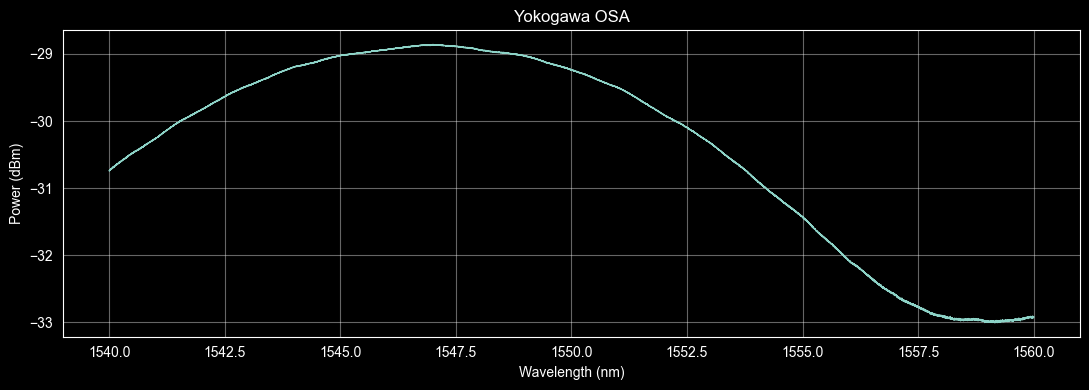

(array([1540.   , 1540.001, 1540.002, ..., 1559.998, 1559.999, 1560.   ],
       shape=(20001,)),
 array([-30.7412825, -30.7424849, -30.7353421, ..., -32.9117775,
        -32.9187314, -32.9253521], shape=(20001,)))

In [24]:
# ── Example 1: Configure and plot ────────────────────────────────────────────
osa_configure()
osa_plot_trace(title="Yokogawa OSA", save_png=True)

In [6]:
# ── Example 2: Find peak wavelength and power ─────────────────────────────────
osa_configure()
osa_single_sweep()
wl, pw = osa_peak_search()
print(f"Peak wavelength: {wl:.4f} nm at {pw:.3f} dBm")

OSA configured: CWL=1550.000 nm, SPAN=40.000 nm, RES=0.020 nm, SENS=NAUT, POINTS=1001
OSA single sweep complete (trace TRA).


KeyboardInterrupt: 

In [ ]:
# ── Example 3: 3 dB spectral width ───────────────────────────────────────────
osa_configure(resolution_nm=0.05)
osa_single_sweep()
width = osa_spectrum_width(thresh_db=3.0)

In [27]:
# ── Example 4: Save trace to CSV ─────────────────────────────────────────────
df = osa_save_trace()
display(df.head())

OSA single sweep complete (trace TRA).
Fetched 20001 points from TRA: 1540.000 – 1560.000 nm
Saved → ./data_osa\osa_trace_20260529_115145.csv


,wavelength_nm,power_dbm
0,1540.000,-30.748901
1,1540.001,-30.746687
2,1540.002,-30.750911
3,1540.003,-30.752645
4,1540.004,-30.746152


In [55]:
# ── Example 5: WDM channel analysis ──────────────────────────────────────────
osa_configure(center_nm=1550.0, span_nm=40.0, resolution_nm=0.05)
osa_single_sweep()
df_wdm = osa_wdm_analysis()
display(df_wdm)

OSA configured: CWL=1550.000 nm, SPAN=40.000 nm, RES=0.050 nm, SENS=NAUT, POINTS=10001
OSA single sweep complete (trace TRA).


VisaIOError: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.

In [1]:
# ── Example 6: Start-stop capture with one call ───────────────────────────────
df = osa_wavelength_sweep_capture(
    start_nm=1540.0,
    stop_nm=1560.0,
    resolution_nm=0.02,
    sensitivity='HIGH1'
)
plt.plot(df.wavelength_nm, df.power_dbm)
plt.xlabel('Wavelength (nm)'); plt.ylabel('Power (dBm)')
plt.title('High-resolution scan'); plt.grid(True); plt.show()

NameError: name 'osa_wavelength_sweep_capture' is not defined

In [12]:
# ── Example 7: Query current settings ────────────────────────────────────────
settings = osa_query_settings()

  center_nm: 1550.0
  span_nm: 40.0
  start_nm: 1530.0
  stop_nm: 1570.0
  resolution_nm: 0.02
  sensitivity: 1
  points: 1001


---
## 🔌 Cleanup

In [18]:
osa.write('*GTL')   # Return front-panel control to the operator
osa.close()
rm.close()
print("AQ6370C connection closed.")

AQ6370C connection closed.
